In [3]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch; from torch import nn; from d2l import torch as d2l
if os.path.basename(os.getcwd()) == 'notes': os.chdir('..')
DEV = 'cuda' if torch.cuda.is_available() else 'cpu'   # 优先 CUDA
print('工作目录:', os.getcwd(), '| device:', DEV)

工作目录: d:\github\prediction | device: cpu


In [4]:
# ============================================================
# 数据: 读取站点0 → 80/15/5 分割 → 各子集独立预处理 → MLP 直接多步训练
# 直接多步: 过去 tau=48 步 → 一次输出未来 H=48 步 (无递归, 无误差累积)
# ============================================================
import netCDF4 as nc

def load_station(nc_path, idx=0):
    """读取指定站点 PM2.5, 返回带 datetime 索引的 DataFrame"""
    f = nc.Dataset(nc_path)
    t = f.variables['time'][:]
    dt = pd.Timestamp(f.variables['time'].units.split('since ')[1]) + pd.to_timedelta(t, unit='h')
    pm25 = f.variables['PM2.5'][:, idx]
    f.close()
    df = pd.DataFrame({'PM_Jingan': pm25, 'PM_US Post': pm25, 'PM_Xuhui': pm25}, index=dt)
    df.index.name = 'datetime'
    return df.resample('1h').first()

def split_and_preprocess(df, ratios=(0.80, 0.15, 0.05)):
    """按比例分割后各子集独立预处理 (先分割再插值, 杜绝泄漏)"""
    n = len(df); n1 = int(n * ratios[0]); n2 = int(n * sum(ratios[:2]))
    subs = []
    for raw in [df.iloc[:n1], df.iloc[n1:n2], df.iloc[n2:]]:
        d = raw.copy()
        d['pm_ave'] = d[['PM_Jingan','PM_US Post','PM_Xuhui']].mean(axis=1)
        d['pm_ave'] = d['pm_ave'].interpolate(method='time', limit=168).ffill().bfill()
        subs.append(d)
    return subs

df_raw = load_station('data3/dataset_yrd.nc', idx=0)
df_tr, df_va, df_te = split_and_preprocess(df_raw)
print(f'训练 {len(df_tr)} | 验证 {len(df_va)} | 测试 {len(df_te)}')

# 标准化 (用训练集统计量)
x_tr = torch.tensor(df_tr['pm_ave'].values, dtype=torch.float32).to(DEV)
x_va = torch.tensor(df_va['pm_ave'].values, dtype=torch.float32).to(DEV)
x_te = torch.tensor(df_te['pm_ave'].values, dtype=torch.float32).to(DEV)
mean, std = x_tr.mean(), x_tr.std()
x_tr, x_va, x_te = (x_tr - mean) / std, (x_va - mean) / std, (x_te - mean) / std

# 直接多步滑窗: 过去 tau 步 → 未来 H 步
tau, H = 48, 48
def make_feats(x, tau, H):
    n = len(x) - tau - H + 1
    feats = torch.stack([x[i:i+n] for i in range(tau)], dim=1)        # (n, tau)
    labs  = torch.stack([x[tau+k:tau+k+n] for k in range(H)], dim=1)  # (n, H)
    return feats, labs

ftr_tr, lab_tr = make_feats(x_tr, tau, H)
ftr_va, lab_va = make_feats(x_va, tau, H)
print(f'样本: 训练 {tuple(ftr_tr.shape)}→{tuple(lab_tr.shape)} | 验证 {tuple(ftr_va.shape)}')
train_iter = d2l.load_array((ftr_tr, lab_tr), 16, is_train=True)
val_iter   = d2l.load_array((ftr_va, lab_va), 16, is_train=False)

# MLP 模型
def get_net():
    net = nn.Sequential(nn.Linear(tau, 128), nn.ReLU(), nn.Linear(128, H))
    net.apply(lambda m: nn.init.xavier_uniform_(m.weight) if type(m)==nn.Linear else None)
    return net

loss = nn.MSELoss(reduction='none')
def train(net, tr_it, va_it, loss, epochs, lr, wd=0.002):
    net.to(DEV); opt = torch.optim.Adam(net.parameters(), lr)
    for ep in range(epochs):
        net.train()
        for X, y in tr_it:
            X, y = X.to(DEV), y.to(DEV)
            opt.zero_grad()
            l = loss(net(X), y); l2 = sum((p**2).sum() for p in net.parameters())
            (l.sum() + wd * l2).backward(); opt.step()
        print(f'epoch {ep+1}, train {d2l.evaluate_loss(net,tr_it,loss):.4f}, val {d2l.evaluate_loss(net,va_it,loss):.4f}')

net = get_net()
train(net, train_iter, val_iter, loss, 20, 0.01)

训练 56102 | 验证 10519 | 测试 3507
样本: 训练 (56007, 48)→(56007, 48) | 验证 (10424, 48)
epoch 1, train 0.7504, val 0.3510
epoch 2, train 0.7572, val 0.3755
epoch 3, train 0.7446, val 0.3794
epoch 4, train 0.7493, val 0.3872
epoch 5, train 0.7446, val 0.3537
epoch 6, train 0.7441, val 0.3523
epoch 7, train 0.7528, val 0.4075
epoch 8, train 0.7531, val 0.3855
epoch 9, train 0.7418, val 0.3686
epoch 10, train 0.7677, val 0.4144
epoch 11, train 0.7506, val 0.4109
epoch 12, train 0.7894, val 0.4017
epoch 13, train 0.8040, val 0.4603
epoch 14, train 0.7493, val 0.3574
epoch 15, train 0.7473, val 0.3789
epoch 16, train 0.7491, val 0.3653
epoch 17, train 0.7633, val 0.4252
epoch 18, train 0.7376, val 0.3543
epoch 19, train 0.7491, val 0.3904
epoch 20, train 0.7451, val 0.3769


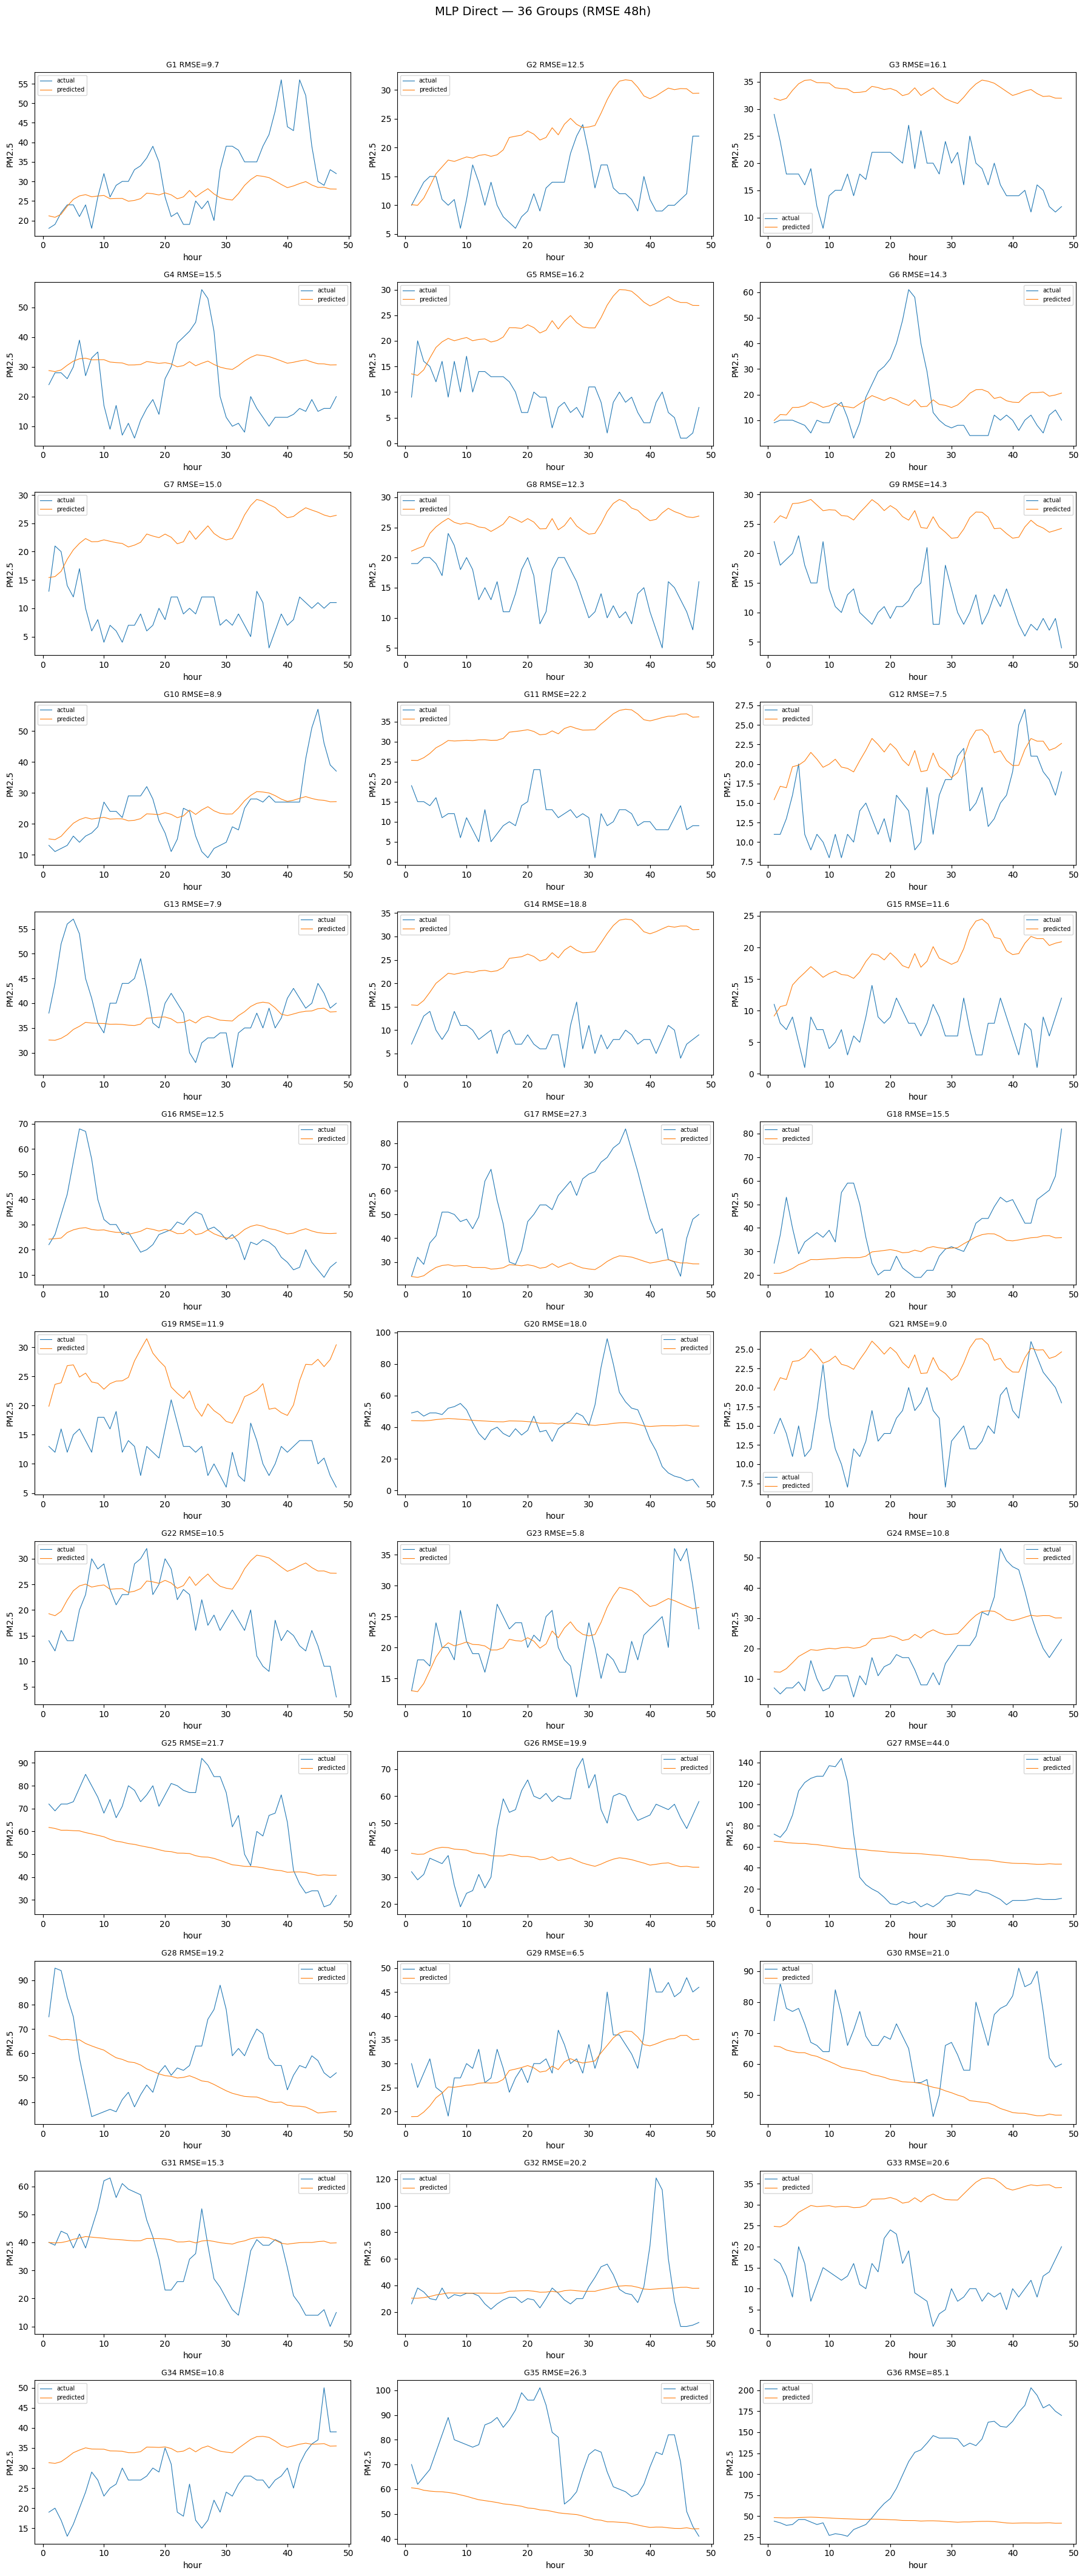


=== 36 组 RMSE 汇总 (48h | 24h) ===
  G 1:   9.67 |   5.79
  G 2:  12.46 |   9.07
  G 3:  16.06 |  15.83
  G 4:  15.47 |  12.93
  G 5:  16.18 |  10.19
  G 6:  14.28 |  16.24
  G 7:  14.98 |  12.69
  G 8:  12.27 |   9.30
  G 9:  14.32 |  13.99
  G10:   8.91 |   5.63
  G11:  22.25 |  18.58
  G12:   7.50 |   8.78
  G13:   7.86 |  10.33
  G14:  18.76 |  13.99
  G15:  11.56 |   9.11
  G16:  12.53 |  14.87
  G17:  27.33 |  20.75
  G18:  15.45 |  15.86
  G19:  11.94 |  11.69
  G20:  18.03 |   6.76
  G21:   8.95 |   9.99
  G22:  10.51 |   4.54
  G23:   5.83 |   3.33
  G24:  10.81 |   9.69
  G25:  21.67 |  20.53
  G26:  19.94 |  16.00
  G27:  43.97 |  50.12
  G28:  19.21 |  16.78
  G29:   6.49 |   4.84
  G30:  21.02 |  12.84
  G31:  15.35 |  12.58
  G32:  20.17 |   5.90
  G33:  20.59 |  15.24
  G34:  10.78 |  10.74
  G35:  26.30 |  30.35
  G36:  85.14 |  28.28

平均 RMSE(48h) = 17.63 | 参考 RMSE(24h) = 13.73


In [5]:
# ============================================================
# 36 组评估: 每组 tau=48h 上下文 → MLP 一次预测 48h, 报告 48h/24h RMSE
# ============================================================
N_GROUPS, N_CTX, N_PRED = 36, tau, H
STRIDE = (len(df_te) - N_CTX - N_PRED) // (N_GROUPS - 1)
actual_all = df_te['pm_ave'].values

rmses, rmses24 = [], []
fig, axes = plt.subplots(12, 3, figsize=(18, 42)); axes = axes.flatten()
for g in range(N_GROUPS):
    s = g * STRIDE
    w = x_te[s:s+tau].reshape(1, -1)                    # (1, tau) 标准化上下文
    with torch.no_grad():
        pred_std = net(w).cpu().numpy().reshape(-1)    # (H,) 移回CPU再转numpy
    preds = pred_std * std.item() + mean.item()        # 反标准化
    actual = actual_all[s+N_CTX:s+N_CTX+N_PRED]
    err2 = (preds - actual) ** 2
    rmses.append(np.sqrt(err2.mean()))                 # 48h RMSE
    rmses24.append(np.sqrt(err2[:24].mean()))           # 前 24h RMSE
    ax = axes[g]; h = np.arange(1, N_PRED+1)
    ax.plot(h, actual, lw=0.8, label='actual')
    ax.plot(h, preds, lw=0.8, label='predicted')
    ax.set_title(f'G{g+1} RMSE={rmses[-1]:.1f}', fontsize=9)
    ax.legend(fontsize=7); ax.set_xlabel('hour'); ax.set_ylabel('PM2.5')
plt.suptitle(f'MLP Direct — {N_GROUPS} Groups (RMSE 48h)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
rmses = np.array(rmses); rmses24 = np.array(rmses24)
print(f'\n=== {N_GROUPS} 组 RMSE 汇总 (48h | 24h) ===')
for g in range(N_GROUPS): print(f'  G{g+1:2d}: {rmses[g]:6.2f} | {rmses24[g]:6.2f}')
print(f'\n平均 RMSE(48h) = {rmses.mean():.2f} | 参考 RMSE(24h) = {rmses24.mean():.2f}')